<a href="https://colab.research.google.com/github/gideonadeti/learning-machine-learning/blob/main/Semi_supervised_Learning%2C_Collaborative_Filtering%2C_and_Content_Based_Filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn import datasets
from sklearn.semi_supervised import LabelPropagation
from sklearn.svm import SVC
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.stats import pearsonr
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split

# For nicer plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

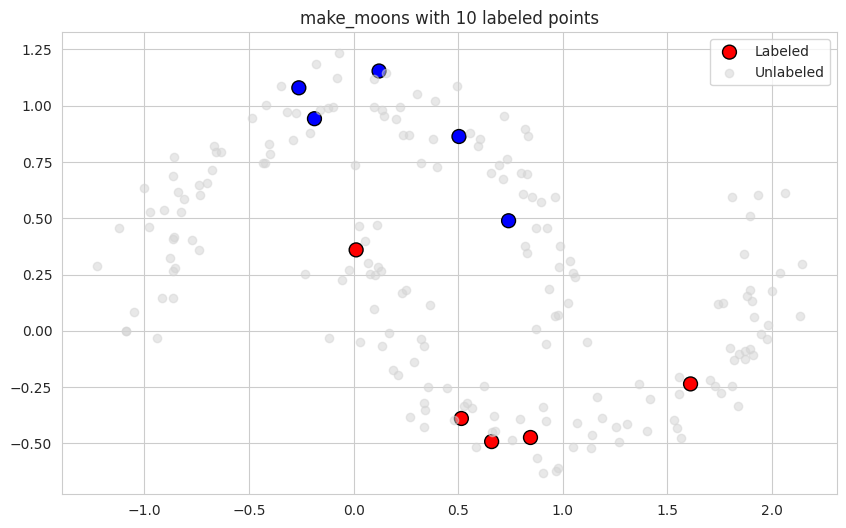

In [5]:
# Generate 200 points with some noise
X, y = datasets.make_moons(n_samples=200, noise=0.1, random_state=42)

# Keep only 5 labeled points per class (10 total)
rng = np.random.RandomState(42)
n_labeled = 5
indices = np.arange(len(y))
# Randomly select 5 indices from each class
labeled_indices = []
for cls in [0, 1]:
    cls_indices = indices[y == cls]
    labeled_indices.extend(rng.choice(cls_indices, n_labeled, replace=False))

# Create a labeled mask (True for labeled points)
is_labeled = np.zeros(len(y), dtype=bool)
is_labeled[labeled_indices] = True

# We'll store the true labels for evaluation, but only use the labeled ones for training
y_labeled = y.copy()
y_labeled[~is_labeled] = -1   # -1 indicates unlabeled for LabelPropagation

# Let's visualize
plt.scatter(X[is_labeled, 0], X[is_labeled, 1], c=y[is_labeled], s=100, edgecolor='k', cmap='bwr', label='Labeled')
plt.scatter(X[~is_labeled, 0], X[~is_labeled, 1], c='lightgray', alpha=0.5, label='Unlabeled')
plt.title(f'make_moons with {n_labeled*2} labeled points')
plt.legend()
plt.show()

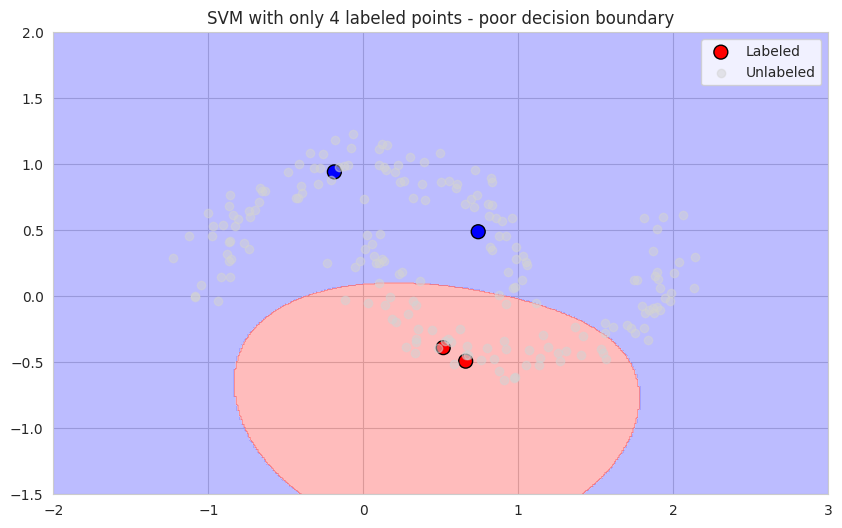

In [3]:
# Train SVM on labeled data only
svm = SVC(kernel='rbf', gamma=1, C=10)
svm.fit(X[is_labeled], y[is_labeled])

# Create a mesh to plot decision boundary
xx, yy = np.meshgrid(np.linspace(-2, 3, 500), np.linspace(-1.5, 2, 500))
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[is_labeled, 0], X[is_labeled, 1], c=y[is_labeled], s=100, edgecolor='k', cmap='bwr', label='Labeled')
plt.scatter(X[~is_labeled, 0], X[~is_labeled, 1], c='lightgray', alpha=0.5, label='Unlabeled')
plt.title('SVM with only 4 labeled points - poor decision boundary')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(


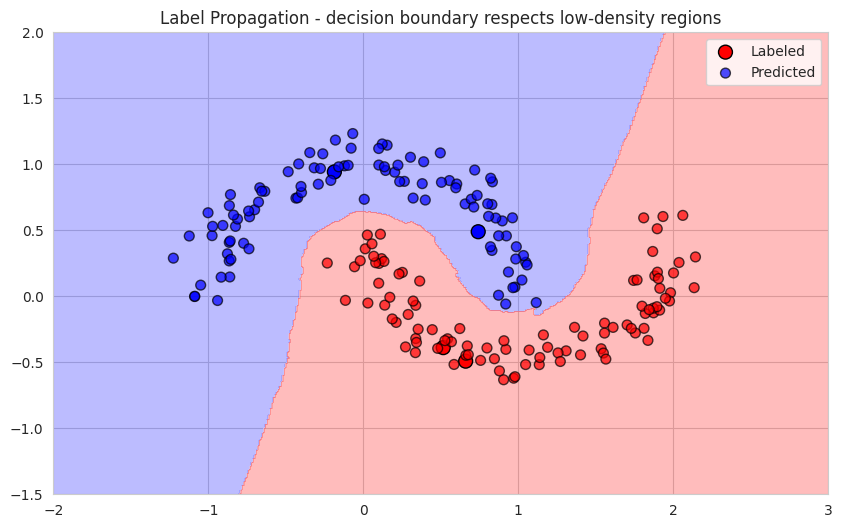

In [4]:
# Apply Label Propagation
lp = LabelPropagation(kernel='knn', n_neighbors=10, max_iter=1000)
lp.fit(X, y_labeled)   # y_labeled has -1 for unlabeled

# Predict on all points
y_pred_lp = lp.predict(X)

# Visualize decision boundary
Z_lp = lp.predict(np.c_[xx.ravel(), yy.ravel()])
Z_lp = Z_lp.reshape(xx.shape)

plt.contourf(xx, yy, Z_lp, alpha=0.3, cmap='bwr')
plt.scatter(X[is_labeled, 0], X[is_labeled, 1], c=y[is_labeled], s=100, edgecolor='k', cmap='bwr', label='Labeled')
plt.scatter(X[~is_labeled, 0], X[~is_labeled, 1], c=y_pred_lp[~is_labeled], s=50, edgecolor='k', cmap='bwr', alpha=0.7, label='Predicted')
plt.title('Label Propagation - decision boundary respects low-density regions')
plt.legend()
plt.show()

### Mini-Exercise: Parameter Experiments
In this section, we compare an SVM with a higher gamma and Label Propagation with a different neighbor count using 10 labeled points (5 per class).

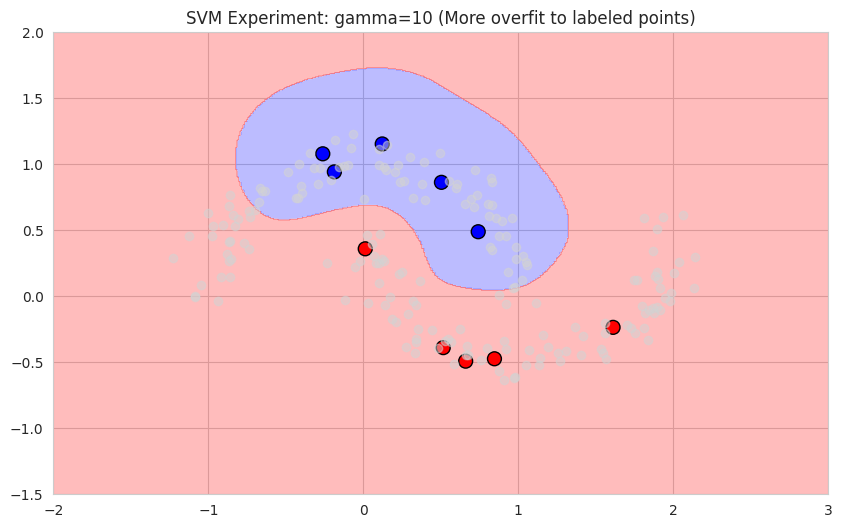

In [6]:
# SVM Experiment: High Gamma
# High gamma makes the decision boundary more 'tight' around individual points
svm_exp = SVC(kernel='rbf', gamma=10, C=10)
svm_exp.fit(X[is_labeled], y[is_labeled])

Z_exp = svm_exp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z_exp, alpha=0.3, cmap='bwr')
plt.scatter(X[is_labeled, 0], X[is_labeled, 1], c=y[is_labeled], s=100, edgecolor='k', cmap='bwr', label='Labeled')
plt.scatter(X[~is_labeled, 0], X[~is_labeled, 1], c='lightgray', alpha=0.5, label='Unlabeled')
plt.title('SVM Experiment: gamma=10 (More overfit to labeled points)')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


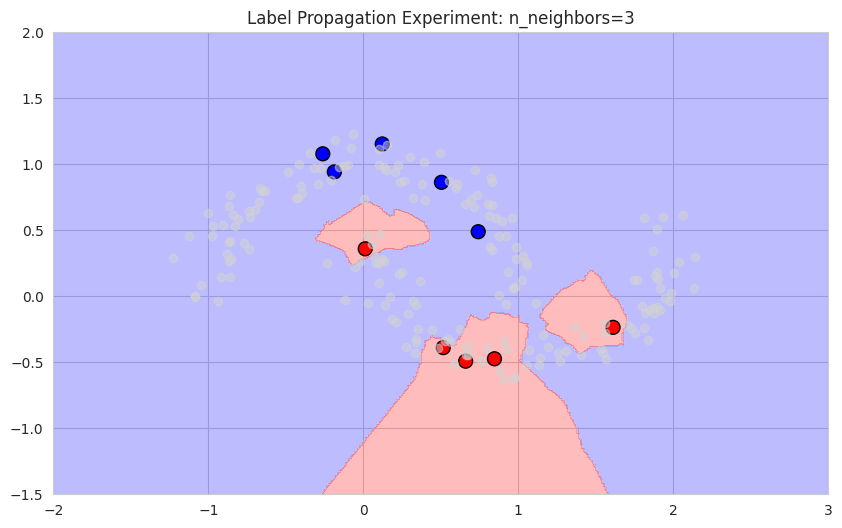

In [7]:
# Label Propagation Experiment: Adjusting n_neighbors
# Small n_neighbors makes the model more sensitive to local structure
lp_exp = LabelPropagation(kernel='knn', n_neighbors=3, max_iter=1000)
lp_exp.fit(X, y_labeled)

Z_lp_exp = lp_exp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z_lp_exp, alpha=0.3, cmap='bwr')
plt.scatter(X[is_labeled, 0], X[is_labeled, 1], c=y[is_labeled], s=100, edgecolor='k', cmap='bwr', label='Labeled')
plt.scatter(X[~is_labeled, 0], X[~is_labeled, 1], c='lightgray', alpha=0.5, label='Unlabeled')
plt.title('Label Propagation Experiment: n_neighbors=3')
plt.show()

In [8]:
# User-Item matrix (rows = users, columns = items)
ratings = pd.DataFrame({
    'Item1': [5, 3, 4, 4, np.nan],
    'Item2': [3, np.nan, 2, 5, 4],
    'Item3': [4, 2, 5, 3, 3],
    'Item4': [np.nan, 4, 3, 2, 5]
}, index=['User1', 'User2', 'User3', 'User4', 'User5'])

print("User-Item Matrix:")
print(ratings)

User-Item Matrix:
       Item1  Item2  Item3  Item4
User1    5.0    3.0      4    NaN
User2    3.0    NaN      2    4.0
User3    4.0    2.0      5    3.0
User4    4.0    5.0      3    2.0
User5    NaN    4.0      3    5.0


In [10]:
import numpy as np
import pandas as pd

# Compute cosine similarity (we'll use pairwise on the DataFrame with NaNs)
# We need to fill NaNs with 0 for cosine? Better to compute only on common items.
# Let's implement a function that computes similarity on common ratings.

def cosine_similarity_users(df, user1, user2):
    """Compute cosine similarity between two users based on common rated items."""
    # Get columns where both users have non-NaN values
    common = df.loc[[user1, user2]].dropna(axis=1, how='any')

    if common.shape[1] == 0:
        return np.nan

    # Convert to flat numpy arrays (1D)
    vec1 = common.loc[user1].to_numpy().flatten()
    vec2 = common.loc[user2].to_numpy().flatten()

    # Cosine similarity calculation
    dot = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    if norm1 == 0 or norm2 == 0:
        return np.nan

    return dot / (norm1 * norm2)

# Compute all pairwise cosine similarities
users = ratings.index
cos_sim = pd.DataFrame(index=users, columns=users, dtype=float)
for u1 in users:
    for u2 in users:
        cos_sim.loc[u1, u2] = cosine_similarity_users(ratings, u1, u2)

print("Cosine Similarity between users:")
print(cos_sim.round(2))

# Pearson correlation using pandas corr (handles NaNs naturally)
pearson_sim = ratings.T.corr()  # .T to compute correlations between rows (users)
print("\nPearson Correlation between users:")
print(pearson_sim.round(2))

Cosine Similarity between users:
       User1  User2  User3  User4  User5
User1   1.00   1.00   0.97   0.94   0.96
User2   1.00   1.00   0.89   0.90   1.00
User3   0.97   0.89   1.00   0.87   0.87
User4   0.94   0.90   0.87   1.00   0.89
User5   0.96   1.00   0.87   0.89   1.00

Pearson Correlation between users:
       User1  User2  User3  User4  User5
User1   1.00    1.0   0.65  -0.50  -1.00
User2   1.00    1.0  -1.00  -0.50   1.00
User3   0.65   -1.0   1.00  -0.40  -0.65
User4  -0.50   -0.5  -0.40   1.00  -0.33
User5  -1.00    1.0  -0.65  -0.33   1.00


In [11]:
def predict_rating(df, target_user, item, sim_matrix, k=2):
    """
    Predict rating for target_user and item using user-based CF.
    sim_matrix: DataFrame of user similarities.
    k: number of nearest neighbors to consider.
    """
    # Users who rated the item
    rated_users = df[item].dropna().index.tolist()
    if not rated_users:
        return np.nan

    # Compute similarities between target and those users
    sims = sim_matrix.loc[target_user, rated_users].dropna()
    if sims.empty:
        return np.nan

    # Sort by similarity descending
    sims_sorted = sims.sort_values(ascending=False)
    # Take top k (or fewer if less)
    neighbors = sims_sorted.head(k)

    # Get ratings of these neighbors for the item
    neighbor_ratings = df.loc[neighbors.index, item]
    # Weighted average
    numerator = np.dot(neighbor_ratings, neighbors)
    denominator = neighbors.sum()
    if denominator == 0:
        return np.nan
    return numerator / denominator

# Predict User5's rating for Item1
pred = predict_rating(ratings, 'User5', 'Item1', cos_sim, k=2)
print(f"Predicted rating for User5 on Item1: {pred:.2f}")

# Let's check if we can also use Pearson similarity
pred_pearson = predict_rating(ratings, 'User5', 'Item1', pearson_sim, k=2)
print(f"Using Pearson correlation: {pred_pearson:.2f}")

Predicted rating for User5 on Item1: 3.98
Using Pearson correlation: 2.51


### 2.4 Mini-Exercise: Item-Based Collaborative Filtering
In IBCF, we compute similarity between columns (items) and predict a rating based on the user's existing ratings for similar items.

In [12]:
def get_item_sim_matrix(df, metric='cosine'):
    """Compute item-item similarity matrix."""
    if metric == 'cosine':
        # Transpose to get items as rows for similarity calculation
        # We'll fill NaNs with 0 for a standard item-cosine approach
        item_data = df.T.fillna(0)
        sim = cosine_similarity(item_data)
        return pd.DataFrame(sim, index=df.columns, columns=df.columns)

    elif metric == 'euclidean':
        item_data = df.T.fillna(0)
        dist = euclidean_distances(item_data)
        # Convert distance to similarity: 1 / (1 + dist)
        sim = 1 / (1 + dist)
        return pd.DataFrame(sim, index=df.columns, columns=df.columns)

# Calculate both matrices
item_sim_cos = get_item_sim_matrix(ratings, 'cosine')
item_sim_euc = get_item_sim_matrix(ratings, 'euclidean')

print("Item-Item Cosine Similarity:")
display(item_sim_cos.round(2))

Item-Item Cosine Similarity:


,Item1,Item2,Item3,Item4
Item1,1.00,0.72,0.90,0.54
Item2,0.72,1.00,0.84,0.67
Item3,0.90,0.84,1.00,0.75
Item4,0.54,0.67,0.75,1.00


In [13]:
def predict_rating_item_based(df, target_user, target_item, sim_matrix, k=2):
    """Predict rating using Item-Based CF."""
    # Items that the target user has actually rated
    user_ratings = df.loc[target_user].dropna()
    if user_ratings.empty:
        return np.nan

    # Similarities between target_item and items the user rated
    sims = sim_matrix.loc[target_item, user_ratings.index]

    # Pick top k neighbors (items)
    neighbors = sims.sort_values(ascending=False).head(k)

    # Weighted average of user's ratings for those similar items
    numerator = np.dot(user_ratings[neighbors.index], neighbors)
    denominator = neighbors.sum()

    return numerator / denominator if denominator != 0 else np.nan

# Experimenting with different k values and metrics
for k_val in [1, 2, 3]:
    p_cos = predict_rating_item_based(ratings, 'User5', 'Item1', item_sim_cos, k=k_val)
    p_euc = predict_rating_item_based(ratings, 'User5', 'Item1', item_sim_euc, k=k_val)
    print(f"k={k_val} | Cosine Pred: {p_cos:.2f} | Euclidean Pred: {p_euc:.2f}")

k=1 | Cosine Pred: 3.00 | Euclidean Pred: 3.00
k=2 | Cosine Pred: 3.44 | Euclidean Pred: 3.40
k=3 | Cosine Pred: 3.83 | Euclidean Pred: 3.79


### Extension: The Cold-Start Problem

When a new user joins (Cold-Start), collaborative filtering fails because there is no history to find neighbors or calculate similarities. Common strategies to handle this include:

1.  **Popularity-Based**: Recommend the overall top-rated or trending items.
2.  **Content-Based**: Use metadata (e.g., genre, description) to suggest items similar to what the user expressed interest in during sign-up.
3.  **Knowledge-Based**: Ask the user for their preferences (e.g., 'Which genres do you like?') to bootstrap the profile.
4.  **Default Ratings**: Use a global mean rating until enough data is collected.

In [14]:
# Item profiles: movies with genre tags
movies = pd.DataFrame({
    'Movie': ['The Matrix', 'The Hangover', 'The Godfather', 'Interstellar', 'Bridesmaids'],
    'Action': [1, 0, 0, 1, 0],
    'Comedy': [0, 1, 0, 0, 1],
    'Drama': [1, 0, 1, 1, 0],
    'SciFi': [1, 0, 0, 1, 0]
})
movies.set_index('Movie', inplace=True)
print("Item Profiles (genres):")
print(movies)

Item Profiles (genres):
               Action  Comedy  Drama  SciFi
Movie                                      
The Matrix          1       0      1      1
The Hangover        0       1      0      0
The Godfather       0       0      1      0
Interstellar        1       0      1      1
Bridesmaids         0       1      0      0


In [15]:
# Compute pairwise Euclidean distance
dist_matrix = euclidean_distances(movies)
dist_df = pd.DataFrame(dist_matrix, index=movies.index, columns=movies.index)
print("Euclidean Distance between movies:")
print(dist_df.round(2))

# Compute dot product (since binary vectors, dot = number of common genres)
dot_matrix = movies.dot(movies.T)
print("\nDot Product (common genres):")
print(dot_matrix)

Euclidean Distance between movies:
Movie          The Matrix  The Hangover  The Godfather  Interstellar  \
Movie                                                                  
The Matrix           0.00          2.00           1.41          0.00   
The Hangover         2.00          0.00           1.41          2.00   
The Godfather        1.41          1.41           0.00          1.41   
Interstellar         0.00          2.00           1.41          0.00   
Bridesmaids          2.00          0.00           1.41          2.00   

Movie          Bridesmaids  
Movie                       
The Matrix            2.00  
The Hangover          0.00  
The Godfather         1.41  
Interstellar          2.00  
Bridesmaids           0.00  

Dot Product (common genres):
Movie          The Matrix  The Hangover  The Godfather  Interstellar  \
Movie                                                                  
The Matrix              3             0              1             3   
The Hangove

In [16]:
liked_movie = 'The Matrix'
# Get distances from the liked movie to all others
distances = dist_df.loc[liked_movie].sort_values()
# Exclude the movie itself
recommendations = distances[distances.index != liked_movie].head(3)
print(f"Movies most similar to '{liked_movie}' (by Euclidean distance):")
print(recommendations)

Movies most similar to 'The Matrix' (by Euclidean distance):
Movie
Interstellar     0.000000
The Godfather    1.414214
The Hangover     2.000000
Name: The Matrix, dtype: float64


In [17]:
# Example: User liked 'The Matrix' and 'The Godfather'
liked_movies = ['The Matrix', 'The Godfather']
user_profile = movies.loc[liked_movies].mean(axis=0)   # average over liked items
print("User profile (average genre preferences):")
print(user_profile)

# Compute distance from user profile to each movie
# We need to treat the profile as a query vector
dist_to_profile = euclidean_distances([user_profile], movies)[0]
# Create a Series
profile_dist = pd.Series(dist_to_profile, index=movies.index)
# Recommend movies with smallest distance, excluding those already liked
recommendations = profile_dist[~profile_dist.index.isin(liked_movies)].sort_values().head(2)
print("\nTop recommendations based on user profile:")
print(recommendations)

User profile (average genre preferences):
Action    0.5
Comedy    0.0
Drama     1.0
SciFi     0.5
dtype: float64

Top recommendations based on user profile:
Movie
Interstellar    0.707107
The Hangover    1.581139
dtype: float64


### 3.5 Mini-Exercise Implementation

**Step 1: Add 'Inception' and re-run recommendation for 'Interstellar'**

In [18]:
new_movie = pd.DataFrame({
    'Action': [1], 'Comedy': [0], 'Drama': [1], 'SciFi': [1]
}, index=['Inception'])

# Update the movies DataFrame
movies_extended = pd.concat([movies, new_movie])

# Re-calculate Euclidean distances
dist_matrix_ext = euclidean_distances(movies_extended)
dist_df_ext = pd.DataFrame(dist_matrix_ext, index=movies_extended.index, columns=movies_extended.index)

# Recommend for someone who liked Interstellar
liked = 'Interstellar'
rec_interstellar = dist_df_ext.loc[liked].sort_values()
rec_interstellar = rec_interstellar[rec_interstellar.index != liked]

print(f"Recommendations for fans of {liked}:")
display(rec_interstellar.head(3))

Recommendations for fans of Interstellar:


,Interstellar
The Matrix,0.000000
Inception,0.000000
The Godfather,1.414214


**Step 2: Change similarity metric to Cosine Similarity**

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute Cosine Similarity
cos_sim_matrix = cosine_similarity(movies_extended)
cos_sim_df = pd.DataFrame(cos_sim_matrix, index=movies_extended.index, columns=movies_extended.index)

# Get rankings for Interstellar using Cosine Similarity (Higher is better)
cos_rec = cos_sim_df.loc['Interstellar'].sort_values(ascending=False)
cos_rec = cos_rec[cos_rec.index != 'Interstellar']

print("Cosine Similarity rankings for 'Interstellar':")
display(cos_rec.head(3))

Cosine Similarity rankings for 'Interstellar':


,Interstellar
The Matrix,1.00000
Inception,1.00000
The Godfather,0.57735


**Step 3: Weighted User Profile**

We will assume a user gave 'The Matrix' a **5.0** and 'The Godfather' a **3.0**. We will use these as weights to bias the profile toward the more highly rated movie.

In [20]:
user_ratings = pd.Series({'The Matrix': 5.0, 'The Godfather': 3.0})

# Normalize weights so they sum to 1
weights = user_ratings / user_ratings.sum()

# Compute weighted average profile
liked_data = movies_extended.loc[user_ratings.index]
weighted_profile = liked_data.T.dot(weights)

print("Weighted User Profile:")
print(weighted_profile)

# Compute similarity of all movies to this weighted profile
# Note: cosine_similarity expects 2D arrays
weighted_sim = cosine_similarity([weighted_profile], movies_extended)[0]
weighted_rec = pd.Series(weighted_sim, index=movies_extended.index).sort_values(ascending=False)

print("\nRecommendations based on Weighted Profile (excluding seen):")
display(weighted_rec[~weighted_rec.index.isin(user_ratings.index)].head(2))

Weighted User Profile:
Action    0.625
Comedy    0.000
Drama     1.000
SciFi     0.625
dtype: float64

Recommendations based on Weighted Profile (excluding seen):


,0
Interstellar,0.973329
Inception,0.973329
